# BERT Mental Health Classification — 5-Model Comparison

**Models:**
- **Model A (Baseline, 256):** lr=2e-5, effective batch=8, 3 epochs, max_length=256
- **Model F (Baseline, 512):** lr=2e-5, effective batch=8, 3 epochs, max_length=512
- **Model O (Warmup, 512):** lr=2e-5, effective batch=8, warmup_ratio=0.1, 3 epochs, max_length=512
- **Model M (Larger Batch + Higher LR, 512):** lr=3e-5, effective batch=32 (4×8), 3 epochs, max_length=512
- **Model M+Warmup (512):** lr=3e-5, effective batch=32 (4×8), warmup_ratio=0.1, 3 epochs, max_length=512

All models use `bert-base-uncased` with standard CrossEntropyLoss.

In [1]:
!pip install -q datasets pandas matplotlib seaborn transformers accelerate scikit-learn

import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


## 1. Load Data & EDA

In [2]:
ds = load_dataset("sai1908/Mental_Health_Condition_Classification")
df = ds["train"].to_pandas()

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nClass distribution:")
print(df["status"].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/791 [00:00<?, ?B/s]

Mental Health Text Dataset for Emotion a(…):   0%|          | 0.00/46.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/103488 [00:00<?, ? examples/s]

Shape: (103488, 2)
Columns: ['text', 'status']
Nulls: 0
Duplicates: 0

Class distribution:
status
anxiety                 17620
normal                  16068
depression              15901
stress                  15230
personality disorder    13915
bipolar                 13708
suicidal                11046
Name: count, dtype: int64


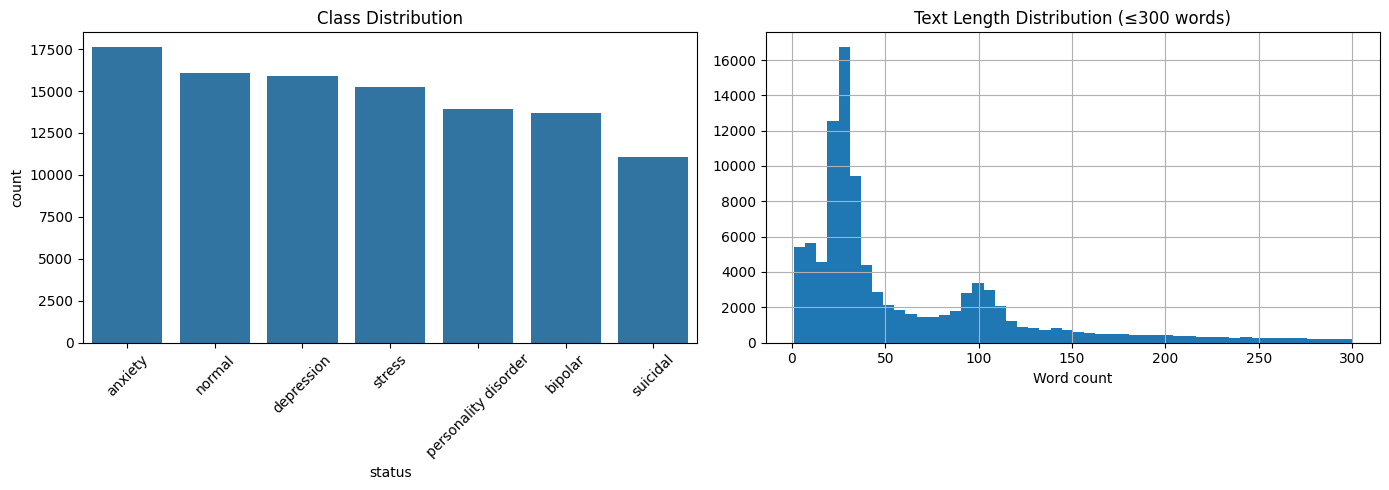

count    103488.000000
mean         82.019365
std         127.863250
min           1.000000
25%          24.000000
50%          34.000000
75%          99.000000
max        5419.000000
Name: word_length, dtype: float64

Texts > 256 words: 6600 (6.38%)
Texts > 512 words: 1614 (1.56%)


In [3]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="status", order=df["status"].value_counts().index, ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].tick_params(axis="x", rotation=45)

# Text length distribution
df["word_length"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df[df["word_length"] <= 300]["word_length"].hist(bins=50, ax=axes[1])
axes[1].set_title("Text Length Distribution (≤300 words)")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.show()

print(df["word_length"].describe())
print(f"\nTexts > 256 words: {(df['word_length'] > 256).sum()} ({(df['word_length'] > 256).mean()*100:.2f}%)")
print(f"Texts > 512 words: {(df['word_length'] > 512).sum()} ({(df['word_length'] > 512).mean()*100:.2f}%)")

## 2. Preprocessing

In [4]:
# Clean text (light cleaning only — BERT handles raw language well)
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

# Encode labels
labels = sorted(df["status"].unique())
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {idx: label for label, idx in label2id.items()}
df["label"] = df["status"].map(label2id)
num_labels = len(labels)

print(f"Classes: {labels}")
print(f"Samples after cleaning: {len(df):,}")

Classes: ['anxiety', 'bipolar', 'depression', 'normal', 'personality disorder', 'stress', 'suicidal']
Samples after cleaning: 103,487


## 3. Train / Validation / Test Split (80/10/10)

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["clean_text", "label"]]),
    "validation": Dataset.from_pandas(val_df[["clean_text", "label"]]),
    "test": Dataset.from_pandas(test_df[["clean_text", "label"]])
})
dataset = dataset.rename_column("clean_text", "text")

for split in dataset:
    if "__index_level_0__" in dataset[split].column_names:
        dataset = dataset.remove_columns(["__index_level_0__"])

Train: 82,789  |  Val: 10,349  |  Test: 10,349


## 4. Tokenization

Each model is tokenized at its own `max_length` (256 for Model A, 512 for the rest),
so we define a helper that builds a tokenized dataset on demand.

In [6]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_dataset(max_length):
    """Tokenize the full DatasetDict at the given max_length and report truncation."""
    def tokenize_fn(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    tokenized = dataset.map(tokenize_fn, batched=True)

    token_lengths = [len(x) for x in tokenized["train"]["input_ids"]]
    n_trunc = sum(1 for l in token_lengths if l == max_length)
    print(f"Token lengths (max_length={max_length}) — "
          f"Min: {min(token_lengths)}, Max: {max(token_lengths)}, "
          f"Mean: {np.mean(token_lengths):.0f}, Median: {np.median(token_lengths):.0f}")
    print(f"Truncated to {max_length}: {n_trunc:,} ({n_trunc/len(token_lengths)*100:.1f}%)")
    return tokenized

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## 5. Evaluation Function

In [7]:
def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_true, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels_true, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

target_names = [id2label[i] for i in range(num_labels)]
print("Ready. Target names:", target_names)

Ready. Target names: ['anxiety', 'bipolar', 'depression', 'normal', 'personality disorder', 'stress', 'suicidal']


## 6. Train 5 Models

| Model | Max Length | Effective Batch | Learning Rate | Warmup | Epochs |
|---|---|---|---|---|---|
| A_baseline | 256 | 8 | 2e-5 | 0.0 | 3 fixed |
| F_baseline_512 | 512 | 8 | 2e-5 | 0.0 | 3 fixed |
| O_warmup_512 | 512 | 8 | 2e-5 | 0.1 | 3 fixed |
| M_larger_batch_higher_lr_512 | 512 | 32 (4×8) | 3e-5 | 0.0 | 3 fixed |
| M_warmup_512 | 512 | 32 (4×8) | 3e-5 | 0.1 | 3 fixed |

In [8]:
# ============================================================
# BERT Fine-Tuning Experiments: A, F, O, M, M+Warmup
# Metrics: Accuracy, Precision, Recall, F1-score
# ============================================================

import gc
from transformers import set_seed

# ------------------------------------------------------------
# 1. Model configurations
# ------------------------------------------------------------
model_configs = {
    "A_baseline": {
        "description": "Baseline BERT fine-tuning (max_length = 256)",
        "max_length": 256,
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "gradient_accumulation_steps": 1,
        "effective_batch_size": 8,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,
        "label_smoothing_factor": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "F_baseline_512": {
        "description": "Baseline setting with max_length = 512",
        "max_length": 512,
        "per_device_train_batch_size": 4,      # reduced because 512 tokens uses more GPU memory
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 2,      # effective batch = 4 x 2 = 8, same as Model A
        "effective_batch_size": 8,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,
        "label_smoothing_factor": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "O_warmup_512": {
        "description": "F_baseline_512 with warmup ratio 0.1",
        "max_length": 512,
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 2,
        "effective_batch_size": 8,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
        "label_smoothing_factor": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "M_larger_batch_higher_lr_512": {
        "description": "Larger effective batch (32) with higher learning rate (3e-5)",
        "max_length": 512,
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 8,      # effective batch = 4 x 8 = 32
        "effective_batch_size": 32,
        "num_train_epochs": 3,
        "learning_rate": 3e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.0,
        "label_smoothing_factor": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },

    "M_warmup_512": {
        "description": "Model M (larger batch + higher lr) with warmup ratio 0.1",
        "max_length": 512,
        "per_device_train_batch_size": 4,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 8,      # effective batch = 4 x 8 = 32
        "effective_batch_size": 32,
        "num_train_epochs": 3,
        "learning_rate": 3e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
        "label_smoothing_factor": 0.0,
        "early_stopping": False,
        "early_stopping_patience": None,
    },
}

# ------------------------------------------------------------
# 2. Storage for results
# ------------------------------------------------------------
all_results = {}
all_reports = {}

# Cache tokenized datasets by max_length so we don't re-tokenize unnecessarily
_tokenized_cache = {}

# ------------------------------------------------------------
# 3. Train and evaluate each model
# ------------------------------------------------------------
for name, cfg in model_configs.items():

    print("\n" + "=" * 80)
    print(f"Training: {name}")
    print(f"Description: {cfg['description']}")
    print(f"Max length: {cfg['max_length']}")
    print(
        f"Batch size: {cfg['per_device_train_batch_size']} x "
        f"{cfg['gradient_accumulation_steps']} = "
        f"{cfg['effective_batch_size']} effective batch size"
    )
    print(f"Learning rate: {cfg['learning_rate']}")
    print(f"Weight decay: {cfg['weight_decay']}")
    print(f"Warmup ratio: {cfg['warmup_ratio']}")
    print(f"Label smoothing: {cfg['label_smoothing_factor']}")
    print(
        f"Epochs: {'up to ' if cfg['early_stopping'] else ''}"
        f"{cfg['num_train_epochs']}"
        f"{' with early stopping' if cfg['early_stopping'] else ' fixed'}"
    )
    print("=" * 80)

    # Reproducibility (reset before every run)
    set_seed(42)

    # Clear memory before each experiment
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Tokenize at this model's max_length (cached per length)
    ml = cfg["max_length"]
    if ml not in _tokenized_cache:
        _tokenized_cache[ml] = tokenize_dataset(ml)
    tokenized_dataset = _tokenized_cache[ml]

    # Fresh model for each experiment
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )

    # Training arguments
    args = TrainingArguments(
        output_dir=f"./{name}",

        eval_strategy="epoch",
        save_strategy="epoch",

        learning_rate=cfg["learning_rate"],
        warmup_ratio=cfg["warmup_ratio"],
        weight_decay=cfg["weight_decay"],
        label_smoothing_factor=cfg["label_smoothing_factor"],

        per_device_train_batch_size=cfg["per_device_train_batch_size"],
        per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
        gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

        num_train_epochs=cfg["num_train_epochs"],

        logging_steps=200,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        save_total_limit=1,
        report_to="none",

        fp16=torch.cuda.is_available(),

        seed=42,
        data_seed=42,
    )

    # Early stopping callback (kept for structural parity; unused by these 5 configs)
    callbacks = []
    if cfg["early_stopping"]:
        callbacks.append(
            EarlyStoppingCallback(early_stopping_patience=cfg["early_stopping_patience"])
        )

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
    )

    # Fine-tune
    train_result = trainer.train()

    # Evaluate
    val_metrics = trainer.evaluate(tokenized_dataset["validation"])
    test_metrics = trainer.evaluate(tokenized_dataset["test"])

    # Classification report on the test set
    pred_output = trainer.predict(tokenized_dataset["test"])
    y_pred = np.argmax(pred_output.predictions, axis=1)
    y_true = pred_output.label_ids
    report = classification_report(
        y_true, y_pred, target_names=target_names, zero_division=0, output_dict=True
    )

    # Store results
    all_results[name] = {
        "Model": name,
        "Description": cfg["description"],
        "Max Length": cfg["max_length"],
        "Learning Rate": cfg["learning_rate"],
        "Weight Decay": cfg["weight_decay"],
        "Warmup Ratio": cfg["warmup_ratio"],
        "Label Smoothing": cfg["label_smoothing_factor"],
        "Train Batch Size": cfg["per_device_train_batch_size"],
        "Gradient Accumulation": cfg["gradient_accumulation_steps"],
        "Effective Batch Size": cfg["effective_batch_size"],
        "Configured Epochs": cfg["num_train_epochs"],
        "Completed Epochs": train_result.metrics.get("epoch"),
        "Early Stopping": cfg["early_stopping"],

        "Train Loss": train_result.training_loss,

        "Validation Loss": val_metrics["eval_loss"],
        "Validation Accuracy": val_metrics["eval_accuracy"],
        "Validation Precision": val_metrics["eval_precision"],
        "Validation Recall": val_metrics["eval_recall"],
        "Validation F1": val_metrics["eval_f1"],

        "Test Loss": test_metrics["eval_loss"],
        "Test Accuracy": test_metrics["eval_accuracy"],
        "Test Precision": test_metrics["eval_precision"],
        "Test Recall": test_metrics["eval_recall"],
        "Test F1": test_metrics["eval_f1"],

        "Best Checkpoint": trainer.state.best_model_checkpoint,
    }
    all_reports[name] = report

    print("\nResult Summary")
    print(f"{name}")
    print(f"Validation F1 : {val_metrics['eval_f1']:.4f}")
    print(f"Test F1       : {test_metrics['eval_f1']:.4f}")
    print(f"Test Accuracy : {test_metrics['eval_accuracy']:.4f}")

    # Clear model from memory before next experiment
    del trainer
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n\n" + "=" * 80)
print("ALL TRAINING COMPLETE")
print("=" * 80)


Training: A_baseline
Description: Baseline BERT fine-tuning (max_length = 256)
Max length: 256
Batch size: 8 x 1 = 8 effective batch size
Learning rate: 2e-05
Weight decay: 0.01
Warmup ratio: 0.0
Label smoothing: 0.0
Epochs: 3 fixed


Map:   0%|          | 0/82789 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Map:   0%|          | 0/10349 [00:00<?, ? examples/s]

Token lengths (max_length=256) — Min: 3, Max: 256, Mean: 84, Median: 47
Truncated to 256: 6,825 (8.2%)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.798578,0.250419,3,0.921442,0.922227,0.921442,0.921610


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.798578,0.259148,3,0.919509,0.919877,0.919509,0.919515



Result Summary
M_warmup_512
Validation F1 : 0.9216
Test F1       : 0.9195
Test Accuracy : 0.9195


ALL TRAINING COMPLETE


## 7. Results Comparison

In [9]:
# ------------------------------------------------------------
# Summary table (sorted by Test F1)
# ------------------------------------------------------------
results_df = pd.DataFrame(all_results).T.reset_index(drop=True)

summary_cols = [
    "Model", "Max Length", "Learning Rate", "Warmup Ratio",
    "Effective Batch Size", "Completed Epochs",
    "Validation F1", "Test Loss", "Test Accuracy", "Test F1",
]
results_df_sorted = results_df.sort_values("Test F1", ascending=False)

display(results_df_sorted[summary_cols])

# Best model
best_model_row = results_df_sorted.iloc[0]
print("\nBest Model:")
print(best_model_row[["Model", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]])

,Model,Max Length,Learning Rate,Warmup Ratio,Effective Batch Size,Completed Epochs,Validation F1,Test Loss,Test Accuracy,Test F1
2,O_warmup_512,512,0.00002,0.1,8,3.0,0.917428,0.391585,0.922311,0.922295
1,F_baseline_512,512,0.00002,0.0,8,3.0,0.919988,0.400069,0.920765,0.92076
3,M_larger_batch_higher_lr_512,512,0.00003,0.0,32,3.0,0.920756,0.266019,0.920572,0.920521
4,M_warmup_512,512,0.00003,0.1,32,3.0,0.92161,0.259148,0.919509,0.919515
0,A_baseline,256,0.00002,0.0,8,3.0,0.915281,0.361478,0.918253,0.918164



Best Model:
Model             O_warmup_512
Test Accuracy         0.922311
Test Precision        0.922825
Test Recall           0.922311
Test F1               0.922295
Name: 2, dtype: object


In [10]:
# ------------------------------------------------------------
# Per-class F1 for every model (highlights depression / suicidal)
# ------------------------------------------------------------
per_class = {}
for name, rep in all_reports.items():
    per_class[name] = {cls: rep[cls]["f1-score"] for cls in target_names}

per_class_df = pd.DataFrame(per_class).T
per_class_df = per_class_df[target_names]  # keep label order
display(per_class_df.style.format("{:.3f}"))

,anxiety,bipolar,depression,normal,personality disorder,stress,suicidal
A_baseline,0.965,0.974,0.798,0.962,0.981,0.954,0.755
F_baseline_512,0.969,0.973,0.805,0.960,0.981,0.954,0.767
O_warmup_512,0.969,0.973,0.809,0.962,0.980,0.957,0.770
M_larger_batch_higher_lr_512,0.968,0.971,0.809,0.958,0.978,0.954,0.769
M_warmup_512,0.968,0.972,0.805,0.961,0.981,0.951,0.761


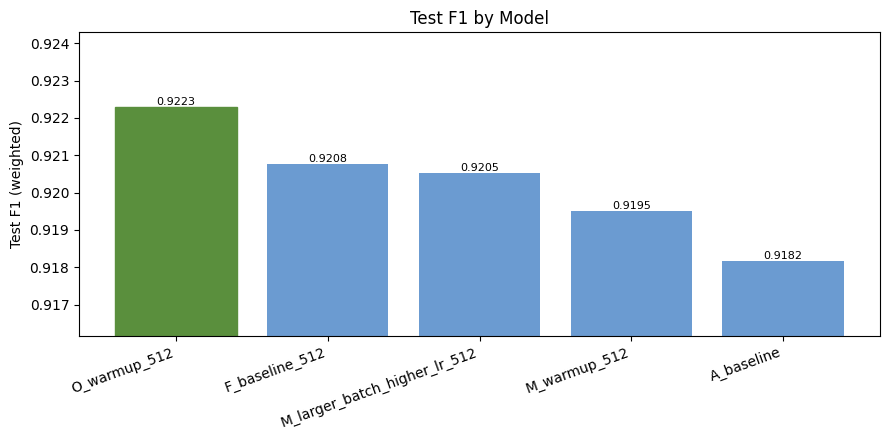

In [11]:
# ------------------------------------------------------------
# Test F1 bar chart
# ------------------------------------------------------------
plot_df = results_df_sorted.set_index("Model")["Test F1"].astype(float)

plt.figure(figsize=(9, 4.5))
bars = plt.bar(plot_df.index, plot_df.values, color="#6B9BD1")
bars[0].set_color("#5A8F3D")  # best
plt.ylim(plot_df.min() - 0.002, plot_df.max() + 0.002)
plt.ylabel("Test F1 (weighted)")
plt.title("Test F1 by Model")
plt.xticks(rotation=20, ha="right")
for b, v in zip(bars, plot_df.values):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()